<a href="https://colab.research.google.com/github/LCaravaggio/FelicidadDesigualdad/blob/main/Sensibilidad_centroides.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
from google.colab import userdata
import json

!mkdir ~/.kaggle
!touch ~/.kaggle/kaggle.json

api_token = {
    'username': userdata.get('KAGGLE_USER'),
    'key': userdata.get('KAGGLE_KEY')}
with open('/root/.kaggle/kaggle.json', 'w') as file:
    json.dump(api_token, file)

!chmod 600 ~/.kaggle/kaggle.json


import kagglehub
eph = kagglehub.dataset_download("leonardocaravaggio/ge-images9")
eph2 = kagglehub.dataset_download("leonardocaravaggio/ge-images5")

mkdir: cannot create directory ‘/root/.kaggle’: File exists


100%|██████████| 0.99G/0.99G [00:12<00:00, 84.0MB/s]

Extracting files...


In [15]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import torch.nn.functional as F
import os
import timm
import torch.nn as nn

# Cargar MobileNetV2 hasta la capa 10
model = models.mobilenet_v2(pretrained=True)
model = nn.Sequential(*list(model.features[:10]))
model.eval()

# Transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def _global_pool(feats: torch.Tensor) -> torch.Tensor:
    # Acepta [B,C,H,W] o [B,L,C]
    if feats.dim() == 4:
        # mapa -> avg pool espacial -> [B, C]
        return F.adaptive_avg_pool2d(feats, (1, 1)).squeeze(-1).squeeze(-1)
    elif feats.dim() == 3:
        # tokens -> promedio sobre L -> [B, C]
        return feats.mean(dim=1)
    else:
        raise RuntimeError(f"Forma de features no esperada: {feats.shape}")

def extract_index(image_path):
    image = Image.open(image_path).convert("RGB")
    x = transform(image).unsqueeze(0)  # [1, 3, 224, 224]
    with torch.no_grad():
        feats = model(x)
        # si algún bloque devuelve una tupla/lista, tomamos el primer tensor
        if isinstance(feats, (list, tuple)):
            feats = feats[0]
        pooled = _global_pool(feats).squeeze(0)  # [C]
        inequality_index = np.std(pooled.cpu().numpy())
    return inequality_index

def compute_inequality(image_5km_path, image_10km_path):
    return {
        "Desigualdad_5km": extract_index(image_5km_path),
        "Desigualdad_10km": extract_index(image_10km_path),
    }

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 110MB/s] 


In [18]:
import os
import shutil

# Ruta de origen y destino
src_dir = eph2+"/Imagenes4"
dst_dir = eph2

# Crear lista de archivos
archivos = os.listdir(src_dir)

# Mover sin sobrescribir
for archivo in archivos:
    origen = os.path.join(src_dir, archivo)
    destino = os.path.join(dst_dir, archivo)

    if not os.path.exists(destino):  # si no existe en destino, mover
        shutil.move(origen, destino)
    else:
        print(f"⚠️ Ya existe: {archivo}, no se movió.")

print("✅ Movimiento completado.")

⚠️ Ya existe: Gran San Luis - 10K.png, no se movió.
⚠️ Ya existe: Gran La Plata - 10K.png, no se movió.
⚠️ Ya existe: Santiago del Estero-La Banda - 10K.png, no se movió.
⚠️ Ya existe: Gran La Plata - 5K.png, no se movió.
⚠️ Ya existe: Gran San Luis - 5K.png, no se movió.
⚠️ Ya existe: Gran La Plata - 1K.png, no se movió.
⚠️ Ya existe: Gran San Luis - 1K.png, no se movió.
✅ Movimiento completado.


In [ ]:
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm
from io import BytesIO

def pil_to_bytes(img):
    buf = BytesIO()
    img.save(buf, format='PNG')
    buf.seek(0)
    return buf

def crop_to_square_center(img, size=1773):
    width, height = img.size
    side = min(width, height, size)
    left = (width - side) // 2
    top = (height - side) // 2
    right = left + side
    bottom = top + side
    return img.crop((left, top, right, bottom))
import os
import pandas as pd
from PIL import Image
from tqdm import tqdm

def limpiar_nombre_central(nombre):
    # "Gran La Plata - 5K.png" -> ("Gran La Plata","5K")
    base = nombre.replace(".png","")
    ciudad, radio = base.rsplit(" - ",1)
    return ciudad.strip(), radio.strip()

def limpiar_nombre_corrida(nombre):
    # "Gran_La_Plata_5K_SurOeste.png" -> ("Gran La Plata","5K","SurOeste")
    base = nombre.replace(".png","")
    parts = base.split("_")
    # partes: ["Gran","La","Plata","5K","SurOeste"]
    ciudad = " ".join(parts[:-2])
    radio = parts[-2]  # "5K" o "10K"
    desplazamiento = parts[-1]
    return ciudad, radio, desplazamiento

carpeta_central = eph2
carpeta_corridas = eph

resultados = []

# --- 1) Centrales (solo 5K y 10K) ---
centrales = [f for f in os.listdir(carpeta_central)
             if f.endswith(".png") and (f.endswith(" - 5K.png") or f.endswith(" - 10K.png"))]

for archivo in tqdm(centrales, desc="Centrales"):
    ciudad, radio = limpiar_nombre_central(archivo)
    path = os.path.join(carpeta_central, archivo)
    img = crop_to_square_center(Image.open(path))
    img_io = pil_to_bytes(img)
    # compute_inequality necesita 2 imágenes, le pasamos la misma
    desigualdad = compute_inequality(img_io, img_io)
    valor = desigualdad["Desigualdad_5km"] if radio == "5K" else desigualdad["Desigualdad_10km"]

    resultados.append({
        "Ciudad": ciudad,
        "Radio": radio,
        "Desplazamiento": "Central",
        "Desigualdad": valor
    })

# --- 2) Corridas (solo 5K y 10K) ---
corridas = [f for f in os.listdir(carpeta_corridas)
            if f.endswith(".png") and ("_5K_" in f or "_10K_" in f)]

for archivo in tqdm(corridas, desc="Corridas"):
    ciudad, radio, desplazamiento = limpiar_nombre_corrida(archivo)
    path = os.path.join(carpeta_corridas, archivo)
    img = crop_to_square_center(Image.open(path))
    img_io = pil_to_bytes(img)
    desigualdad = compute_inequality(img_io, img_io)
    valor = desigualdad["Desigualdad_5km"] if radio == "5K" else desigualdad["Desigualdad_10km"]

    resultados.append({
        "Ciudad": ciudad,
        "Radio": radio,
        "Desplazamiento": desplazamiento,
        "Desigualdad": valor
    })

In [21]:
df = pd.DataFrame(resultados)

# --- 3) Variabilidad separada para 5K y 10K ---
variabilidad = (
    df[df["Desplazamiento"]!="Central"]
    .groupby(["Ciudad","Radio"])["Desigualdad"]
    .agg(["mean","std"])
    .reset_index()
)

# unir con valor central
centrales_df = df[df["Desplazamiento"]=="Central"][["Ciudad","Radio","Desigualdad"]].rename(columns={"Desigualdad":"Central"})
variabilidad = variabilidad.merge(centrales_df, on=["Ciudad","Radio"])
variabilidad["Diff_mean_vs_central"] = variabilidad["mean"] - variabilidad["Central"]

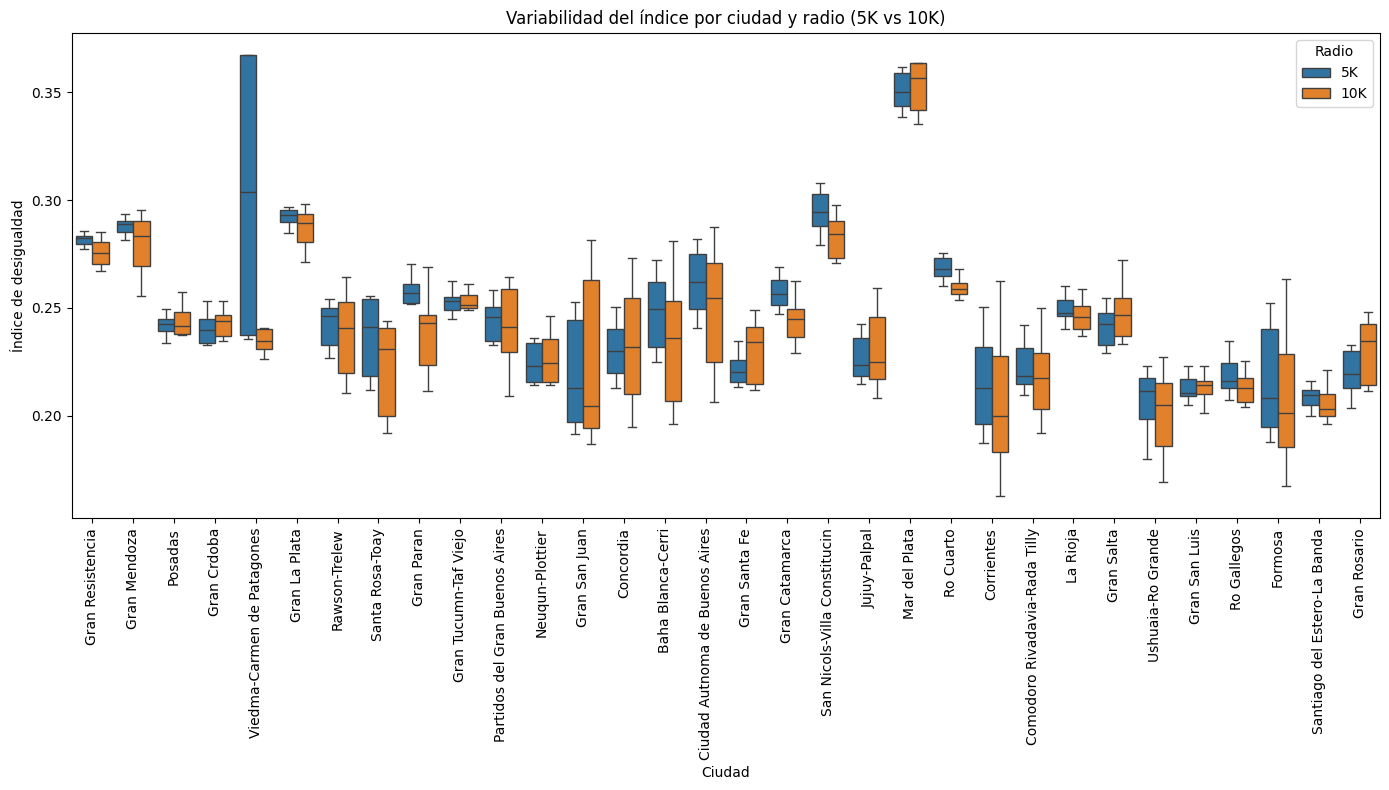

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtramos solo las corridas (no Central)
df_corridas = df[df["Desplazamiento"] != "Central"]

# Ajustamos tamaño general del gráfico
plt.figure(figsize=(14, 8))

# Boxplot: ciudades en eje x, desigualdad en y, separado por Radio
sns.boxplot(
    data=df_corridas,
    x="Ciudad",
    y="Desigualdad",
    hue="Radio",          # colores distintos para 5K y 10K
    showfliers=False      # opcional para ocultar outliers extremos
)

# Rotar etiquetas para que entren
plt.xticks(rotation=90)
plt.title("Variabilidad del índice por ciudad y radio (5K vs 10K)")
plt.xlabel("Ciudad")
plt.ylabel("Índice de desigualdad")

plt.tight_layout()
plt.show()


In [43]:
# Diccionario de corrección manual
correcciones = {
    "Gran Crdoba": "Gran Córdoba",
    "Neuqun-Plottier": "Neuquén-Plottier",
    "Ushuaia-Ro Grande": "Ushuaia-Río Grande",
    "Gran Paran": "Gran Paraná",
    "Ro Cuarto": "Río Cuarto",
    "Baha Blanca-Cerri": "Bahía Blanca-Cerri",
    "Ciudad Autnoma de Buenos Aires": "Ciudad Autónoma de Buenos Aires",
    "San Nicols-Villa Constitucin": "San Nicolás-Villa Constitución",
    "Jujuy-Palpal": "Jujuy-Palpalá",
    "Gran Tucumn-Taf Viejo": "Gran Tucumán-Tafí Viejo",
}

# Reemplazar en df
df["Ciudad"] = df["Ciudad"].replace(correcciones)

ciudades = pd.read_csv("Gini_EPH.csv")
ciudades["Ciudad"]=ciudades["Nombre_Aglomerado"]
df_merged = df.merge(ciudades[["Ciudad","Gini_Hogares"]], on="Ciudad", how="left")

In [44]:
from scipy.stats import pearsonr

resultados_correlacion = []

for radio in ["5K","10K"]:
    for desplazamiento in df_merged["Desplazamiento"].unique():
        df_sub = df_merged[(df_merged["Radio"]==radio) &
                           (df_merged["Desplazamiento"]==desplazamiento)]
        # eliminar nulos
        mask = df_sub["Desigualdad"].notna() & df_sub["Gini_Hogares"].notna()
        if mask.sum()>2:  # al menos 3 puntos para correlación
            r, p = pearsonr(df_sub.loc[mask,"Desigualdad"], df_sub.loc[mask,"Gini_Hogares"])
            resultados_correlacion.append({
                "Radio": radio,
                "Desplazamiento": desplazamiento,
                "r": r,
                "p": p,
                "N": mask.sum()
            })

df_corr = pd.DataFrame(resultados_correlacion)
print(df_corr)


   Radio Desplazamiento         r         p   N
0     5K        Central  0.506565  0.003092  32
1     5K       SurOeste  0.232019  0.209128  31
2     5K        SurEste  0.151835  0.414851  31
3     5K          Oeste  0.236982  0.199277  31
4     5K          Norte  0.360533  0.046322  31
5     5K            Sur  0.228238  0.216854  31
6     5K           Este  0.193076  0.298035  31
7     5K     NorteOeste  0.335438  0.065074  31
8     5K      NorteEste  0.289046  0.114777  31
9    10K        Central  0.438842  0.011984  32
10   10K       SurOeste  0.244162  0.185600  31
11   10K        SurEste  0.037842  0.839833  31
12   10K          Oeste  0.271524  0.139521  31
13   10K          Norte  0.416468  0.019779  31
14   10K            Sur  0.189724  0.306661  31
15   10K           Este  0.110830  0.552812  31
16   10K     NorteOeste  0.298810  0.102493  31
17   10K      NorteEste  0.229216  0.214838  31


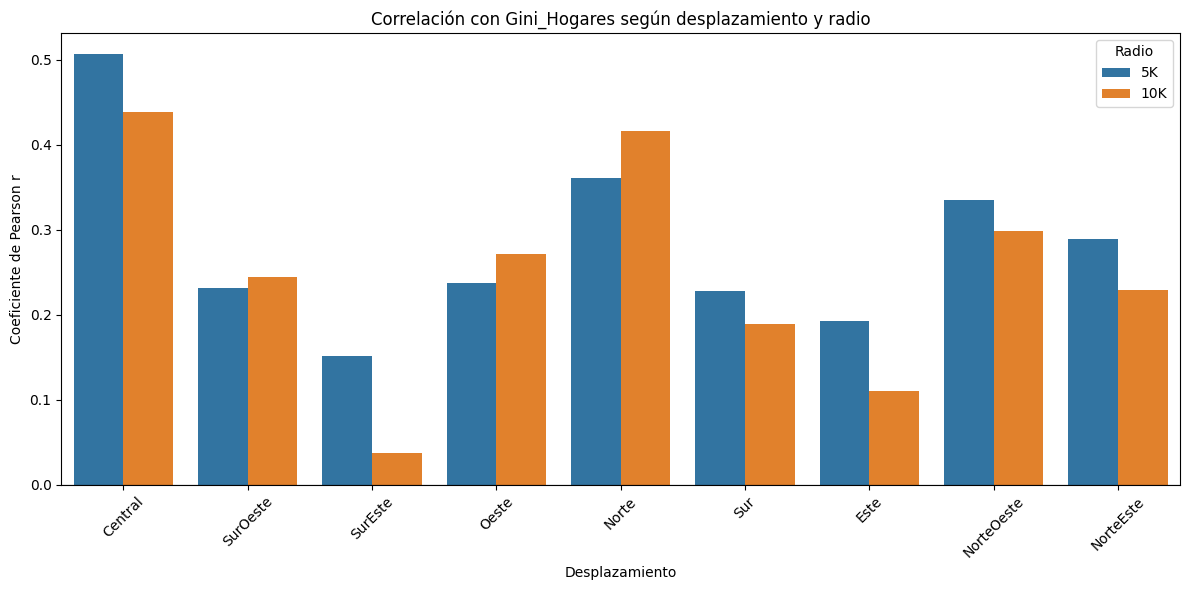

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(data=df_corr, x="Desplazamiento", y="r", hue="Radio")
plt.axhline(0.0,color="black",linewidth=0.8)
plt.title("Correlación con Gini_Hogares según desplazamiento y radio")
plt.ylabel("Coeficiente de Pearson r")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [46]:
import numpy as np
from scipy.stats import pearsonr

resultados_random = []

n_iter = 1000  # cantidad de simulaciones

for radio in ["5K", "10K"]:
    # subset solo de ese radio
    df_radio = df_merged[df_merged["Radio"]==radio]

    ciudades_unicas = df_radio["Ciudad"].unique()

    for i in range(n_iter):
        # Para cada ciudad elegimos un desplazamiento al azar
        muestras = []
        for ciudad in ciudades_unicas:
            df_ciudad = df_radio[df_radio["Ciudad"]==ciudad]
            if not df_ciudad.empty:
                # elegir fila random
                fila_random = df_ciudad.sample(1)
                muestras.append(fila_random)
        # concatenar en un df
        df_sample = pd.concat(muestras)

        mask = df_sample["Desigualdad"].notna() & df_sample["Gini_Hogares"].notna()

        if mask.sum()>2:
            r, p = pearsonr(df_sample.loc[mask,"Desigualdad"],
                            df_sample.loc[mask,"Gini_Hogares"])
            resultados_random.append({
                "Radio": radio,
                "Iteracion": i,
                "r": r,
                "p": p,
                "N": mask.sum()
            })

df_random = pd.DataFrame(resultados_random)


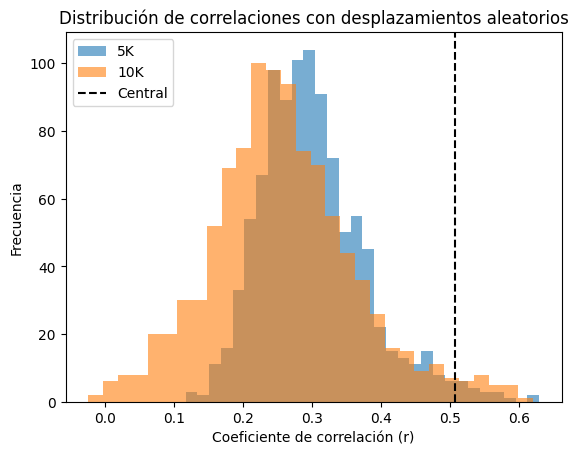

In [48]:
df_random.groupby("Radio")["r"].agg(["mean","std"])
import matplotlib.pyplot as plt

for radio in ["5K","10K"]:
    plt.hist(df_random[df_random["Radio"]==radio]["r"], bins=30, alpha=0.6, label=radio)

plt.axvline(x=df_corr[df_corr["Desplazamiento"]=="Central"]["r"].values[0], color='k', linestyle='--', label="Central")
plt.legend()
plt.xlabel("Coeficiente de correlación (r)")
plt.ylabel("Frecuencia")
plt.title("Distribución de correlaciones con desplazamientos aleatorios")
plt.show()
